## ENN - another undersampling method

ENN is fairly aggressive in removing data rows, so this is just an alternative if you wish to try this.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import EditedNearestNeighbours
import matplotlib.pyplot as plt

df = pd.read_csv("winequality-red.csv")

# X/y -split
X = df.drop("quality", axis=1)
y = df['quality']

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

# enn = EditedNearestNeighbours(n_neighbors=3)
enn = EditedNearestNeighbours(n_neighbors=3, sampling_strategy=[5, 6])
X_resampled, y_resampled = enn.fit_resample(X_train, y_train)

print(f"Original data shape: {X_train.shape}, {y_train.shape}")
print(f"Resampled data shape: {X_resampled.shape}, {y_resampled.shape}")

Original data shape: (1119, 11), (1119,)
Resampled data shape: (398, 11), (398,)


In [3]:
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['quality'] = y_resampled

<Axes: >

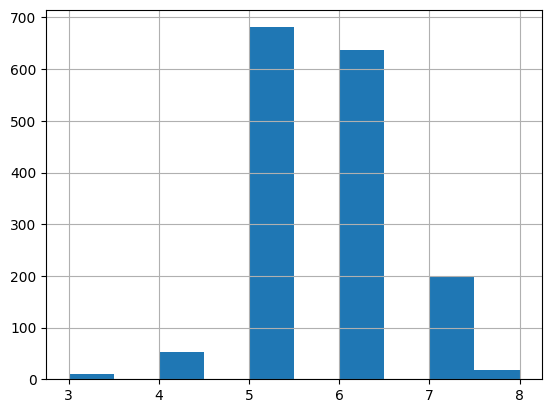

In [4]:
df['quality'].hist()


<Axes: >

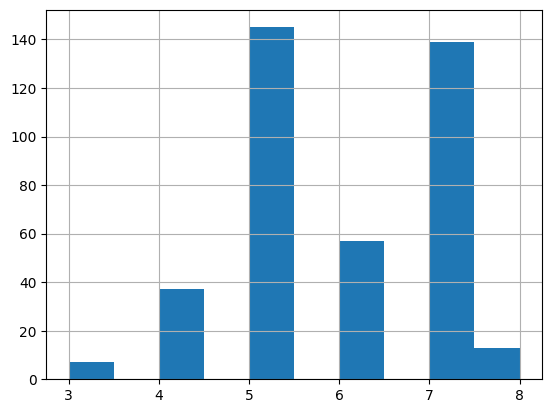

In [5]:
df_resampled['quality'].hist()

C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_11400\2812027548.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='alcohol', data=df_resampled, palette='coolwarm')


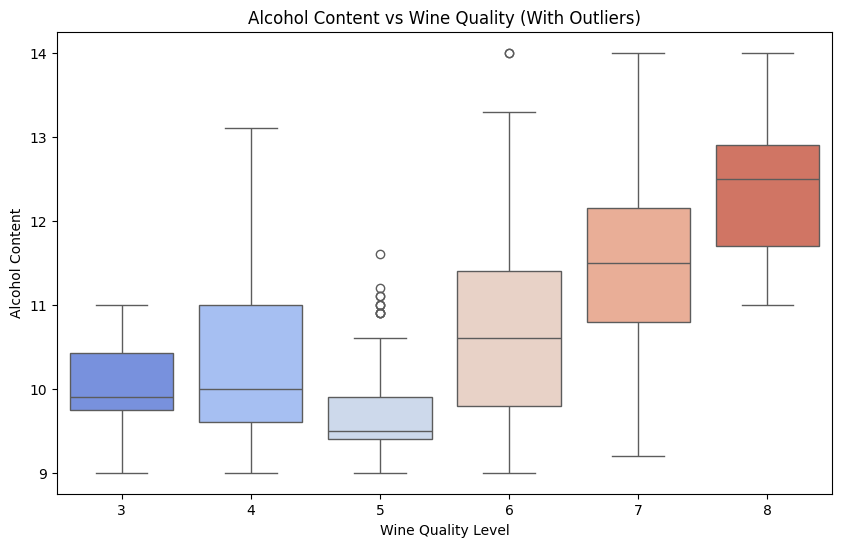

In [6]:
# boxplot version
import seaborn as sns
import matplotlib.pyplot as plt

# Example box plot for alcohol content across wine quality levels
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='alcohol', data=df_resampled, palette='coolwarm')
plt.title('Alcohol Content vs Wine Quality (With Outliers)')
plt.xlabel('Wine Quality Level')
plt.ylabel('Alcohol Content')
plt.show()


In [7]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_11400\2785455024.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='total sulfur dioxide', data=df_resampled, palette='coolwarm')


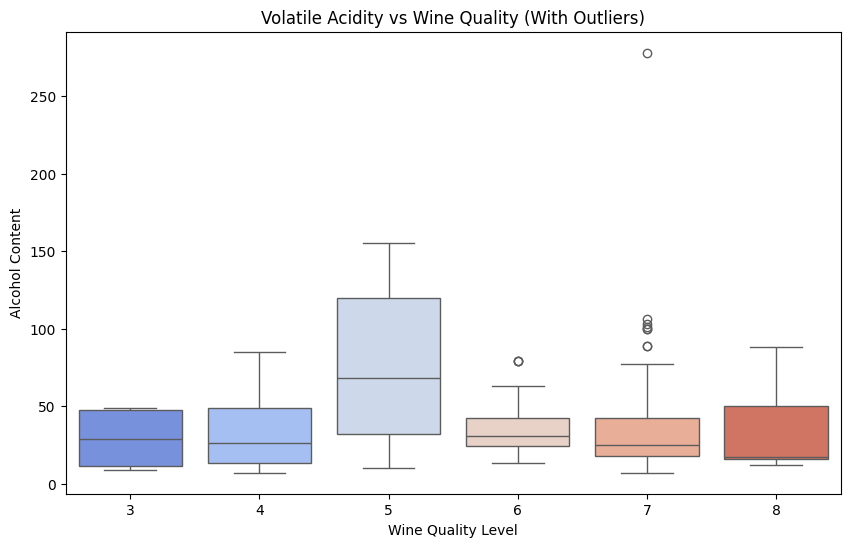

In [8]:
# boxplot version
import seaborn as sns
import matplotlib.pyplot as plt

# Example box plot for alcohol content across wine quality levels
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='total sulfur dioxide', data=df_resampled, palette='coolwarm')
plt.title('Volatile Acidity vs Wine Quality (With Outliers)')
plt.xlabel('Wine Quality Level')
plt.ylabel('Alcohol Content')
plt.show()
